In [1]:
%matplotlib widget
import sys, importlib, os
import McsPy.McsData
import McsPy.McsCMOS
from McsPy import ureg, Q_

# matplotlib.pyplot will be used in these examples to generate the plots visualizing the data
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.widgets import Slider
import numpy as np
from scipy import signal

# import datashader as ds
# import datashader.transfer_functions as tf
import pandas as pd
import numpy as np
# import pynapple as nap


import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

na = np.array
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

import numpy as np
import scipy.signal
import matplotlib.pyplot as plt
import h5py


In [2]:

def detect_extreme_events(signal, window_size=5000, 
                          threshold_std=5, 
                          min_separation=2000, 
                          min_event_length=500, 
                          dt=0.0004):
    """
    Detects events in the signal that are below mean - (threshold_std * std_dev) or above mean + (threshold_std * std_dev),
    extracts windows around the peaks using the Hilbert transform, ensuring minimum separation between events and a minimum event length.

    Parameters:
    signal (np.array): 1D array of signal data.
    window_size (int): Number of samples to include in each window.
    threshold_std (float): Threshold in terms of standard deviations.
    min_separation (int): Minimum number of points between consecutive events.
    min_event_length (int): Minimum length of an event to be considered valid.
    dt (float): Time step for converting indices to time intervals.
    
    Returns:
    list of np.array: Extracted event windows.
    list of list: Time intervals for detected events.
    """
    mean_val = np.mean(signal)
    std_val = np.std(signal)
    lower_threshold = mean_val - (threshold_std * std_val)
    # upper_threshold = mean_val + (threshold_std * std_val)
    
    # Find indices where signal is below or above the threshold
    low_event_indices = np.where(signal < lower_threshold)[0]
    # high_event_indices = np.where(signal > upper_threshold)[0]
    # event_indices = np.sort(np.concatenate((low_event_indices)))#,
    event_indices = np.sort(low_event_indices)#,
    
    # Ensure events are at least min_separation apart
    filtered_indices = []
    last_idx = -min_separation
    for idx in event_indices:
        if idx - last_idx >= min_separation:
            filtered_indices.append(idx)
            last_idx = idx
    
    # Compute Hilbert transform and envelope
    analytic_signal = scipy.signal.hilbert(signal)
    envelope = np.abs(analytic_signal)
    # Extract windows around the peak of the envelope
    windows = []
    intervals = []
    for idx in filtered_indices:
        peak_idx = idx + np.argmax(envelope[idx:idx + window_size])
        start = max(0, peak_idx - window_size // 2)
        end = min(len(signal), peak_idx + window_size // 2)
        
        # Apply minimum event length constraint
        if (end - start) >= min_event_length:
            windows.append(signal[start:end])
            intervals.append([float(start) * dt, float(end) * dt])
    
    return windows, intervals

In [68]:
import numpy as np
import scipy.signal

def detect_extreme_events(signal, 
                          chunk_size=5000, 
                          window_size=5000,
                          threshold_std=5, 
                          min_separation=2000, 
                          min_event_length=500, 
                          dt=0.0004):
    """
    Detects extreme low events in a signal using local (per-chunk) thresholds.
    Applies Hilbert transform to extract peaks, ensuring minimum separation and minimum event length.

    Parameters:
    signal (np.array): 1D array of signal data.
    chunk_size (int): Size of chunks for computing local thresholds.
    window_size (int): Number of samples to extract around each detected event peak.
    threshold_std (float): Threshold in terms of standard deviations (applied locally).
    min_separation (int): Minimum number of points between events.
    min_event_length (int): Minimum length of a detected event.
    dt (float): Time step for converting indices to time.

    Returns:
    list of np.array: Extracted event signal windows.
    list of list: Time intervals for the events in seconds.
    """
    windows = []
    intervals = []

    # Compute Hilbert transform and envelope once for entire signal
    analytic_signal = scipy.signal.hilbert(signal)
    envelope = np.abs(analytic_signal)

    num_chunks = int(np.ceil(len(signal) / chunk_size))
    for i in range(num_chunks):
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, len(signal))
        chunk = signal[start_idx:end_idx]
        
        if len(chunk) < min_event_length:
            continue  # Skip small chunks
        
        # Local stats
        mean_val = np.mean(chunk)
        std_val = np.std(chunk)
        upper_threshold = mean_val + (threshold_std * std_val)

        # Local extreme low indices
        local_indices = np.where(chunk > upper_threshold)[0] + start_idx

        # Filter by minimum separation
        filtered_indices = []
        last_idx = -min_separation
        for idx in local_indices:
            if idx - last_idx >= min_separation:
                filtered_indices.append(idx)
                last_idx = idx

        # Extract windows centered at local peak of the envelope
        for idx in filtered_indices:
            peak_idx = idx + np.argmax(envelope[idx:min(idx + window_size, len(signal))])
            window_start = max(0, peak_idx - window_size // 2)
            window_end = min(len(signal), peak_idx + window_size // 2)

            if (window_end - window_start) >= min_event_length:
                windows.append(signal[window_start:window_end])
                intervals.append([float(window_start) * dt, float(window_end) * dt])

    return windows, intervals

In [3]:
import stumpy

In [4]:

# file_name = '/Users/ovinogradov/Documents/Projects/SCN1A/MEA-analysis/data/Shaima_example/2025-01-17T21-17-46McsRecording.h5'

['/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-15-02McsRecording.h5_filtered.h5',

'/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-29-29McsRecording.h5_filtered.h5'
 
 '/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-52-02McsRecording.h5_filtered.h5'
]

# target_file ='/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_21-03-25_slice6_2025-03-21T14-42-46McsRecording.h5_filtered.h5'
target_file = '/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_21-03-25_slice6_2025-03-21T14-52-28McsRecording.h5_filtered.h5'#/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-15-02McsRecording.h5_filtered.h5'
#'/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_03-12-24_slice1_2024-12-03T10-29-29McsRecording.h5_filtered.h5'#'/home/ovinogradov/Projects/MEA-analysis/data/R1648H_filt/R1648H_21-03-25_slice6_2025-03-21T14-52-28McsRecording.h5_filtered.h5'
# with h5py.File('filtered.h5', 'r') as f:
with h5py.File(target_file, 'r') as f:
    # print(f.keys())
    print(f['data'].shape)
    filt = f['data'][:,:]
    subsampling_rate = f['resampled_rate']
# with h5py.File(file_name, "r") as f:
#     data= f['Data']['Recording_0']['AnalogStream']['Stream_0']['ChannelData']
#     print(data)
#     # chunk_size = 1000  # Choose an optimal chunk size
#     data_series = data[10,:]  # Process in chunks


(4492000, 252)


In [5]:
with h5py.File(target_file, 'r') as f:
    # print(f['data'].shape)
    # filt = f['data'][:,:]
    subsampling_rate = na(f['resampled_rate'])
    adc_step = na(f['scale'])

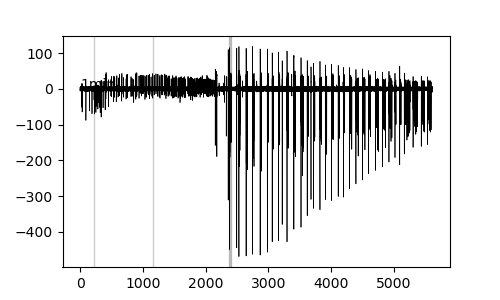

In [53]:
plt.figure(figsize = (5,3))
import matplotlib.patches as patches

#68,70,72,74,76,78
mv_scale_factor =  1000000
plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate),(filt[:,163]*adc_step)*mv_scale_factor,'-',linewidth = 0.5,color='k'),#);
# plt.xlim(85,140.3)
plt.plot([2,3],[-.00005,-.00005],color='k')
plt.text(2.,-.000062,'1min')
blocks = [[222,223],[1157,1158],[2380,2410]]
for block in na(blocks): 
    plt.axvspan(block[0],block[1],color='k',alpha=0.2)
# rect1 = patches.Rectangle((2, 2), 4, 3, linewidth=2, edgecolor='red', facecolor='none')

# plt.plot([-1,-1],[-.00002,.0000],color='k')
# plt.text(-4.,-.0000,'1µV')
# plt.ylim([-5e-5,8e-5])
# plt.axis('off')
plt.show()

# plt.ax

In [39]:
np.abs(filt[:2500,:]).sh

(2500, 252)

In [169]:
# scipy.signal.envelope 


import numpy as np
import scipy.signal

def detect_extreme_events(signal, 
                          chunk_size=5000, 
                          window_size=5000,
                          threshold_std=5, 
                          min_separation=2000, 
                          min_event_length=500, 
                          dt=0.0004):
    """
    Detects extreme low events in a signal using local (per-chunk) thresholds.
    Applies Hilbert transform to extract peaks, ensuring minimum separation and minimum event length.

    Parameters:
    signal (np.array): 1D array of signal data.
    chunk_size (int): Size of chunks for computing local thresholds.
    window_size (int): Number of samples to extract around each detected event peak.
    threshold_std (float): Threshold in terms of standard deviations (applied locally).
    min_separation (int): Minimum number of points between events.
    min_event_length (int): Minimum length of a detected event.
    dt (float): Time step for converting indices to time.

    Returns:
    list of np.array: Extracted event signal windows.
    list of list: Time intervals for the events in seconds.
    """
    windows = []
    intervals = []

    # Compute Hilbert transform and envelope once for entire signal
    analytic_signal = scipy.signal.hilbert(signal)
    envelope = np.abs(analytic_signal)
    baselines = []
    used_ranges = []  # to store [start, end) of accepted windows

    num_chunks = int(np.ceil(len(signal) / chunk_size))
    for i in range(num_chunks):
        start_idx = i * chunk_size
        end_idx = min((i + 1) * chunk_size, len(signal))
        chunk = envelope[start_idx:end_idx]
        
        if len(chunk) < min_event_length:
            continue  # Skip small chunks
        
        # Local stats
        mean_val = np.mean(chunk)
        std_val = np.std(chunk)
        upper_threshold = mean_val + (threshold_std * std_val)
        end_threshold = mean_val + (.5* std_val)
        baselines.append([[start_idx,end_idx],[threshold_std*std_val,threshold_std*std_val]])
        
        # Local extreme low indices
        local_indices = np.where(chunk > upper_threshold)[0] + start_idx

        # Filter by minimum separation
        filtered_indices = []
        last_idx = -min_separation
        for idx in local_indices:
            if idx - last_idx >= min_separation:
                filtered_indices.append(idx)
                last_idx = idx

        # Extract windows centered at local peak of the envelope
        for idx in filtered_indices:
            peak_idx = idx + np.argmax(envelope[idx:min(idx + window_size, len(signal))])
            # window_start = max(0, peak_idx - window_size // 2)
            # window_end = min(len(signal), peak_idx + window_size // 2)

            end_idx = peak_idx
            while end_idx < len(signal) and envelope[end_idx] > end_threshold:
                end_idx += 1
            window_start = max(0, peak_idx - window_size // 2)
            window_end =min(len(signal), end_idx)
            
            if (window_end - window_start) < min_event_length:
                continue

            # Check for overlap with previously accepted windows
            overlap = any(
                not (window_end <= existing_start or window_start >= existing_end)
                for existing_start, existing_end in used_ranges
            )
            if overlap:
                continue

            # Accept the window
            windows.append(signal[window_start:window_end])
            intervals.append([float(window_start) * dt, float(window_end) * dt])
            used_ranges.append((window_start, window_end))

    return windows, intervals,baselines

In [172]:
analytic_signal = scipy.signal.hilbert(filt[:,63]*adc_step*mv_scale_factor)
amplitude_envelope = np.abs(analytic_signal)

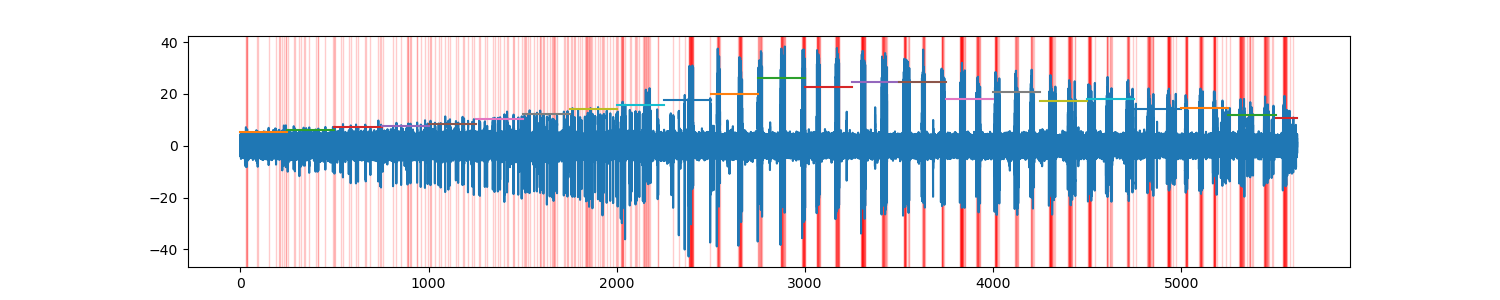

In [175]:

orig_data= filt[:,63]*adc_step*mv_scale_factor
# data= amplitude_envelope[:]
plt.figure(figsize=(15,3))
plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate),orig_data)
# plt.plot(np.arange(0,len(filt[:2500000]))*(1/subsampling_rate),orig_data)
# plt.axhline(np.mean(data)+5*np.std(data))
cutouts, intervals,bl = detect_extreme_events(orig_data, 
                           chunk_size=200000,
                           window_size=100, 
                          threshold_std=5, 
                          min_separation=200, 
                          min_event_length=20, 
                          dt=1/subsampling_rate)
for interv in intervals:
    plt.axvspan(interv[0],interv[1],alpha=0.2,color='r')
for b in bl:
    plt.plot(na(b[0])*(1/subsampling_rate),b[1])
# plt.plot(filt[:,163]*adc_step*mv_scale_factor)

In [158]:
len(cutouts)

675

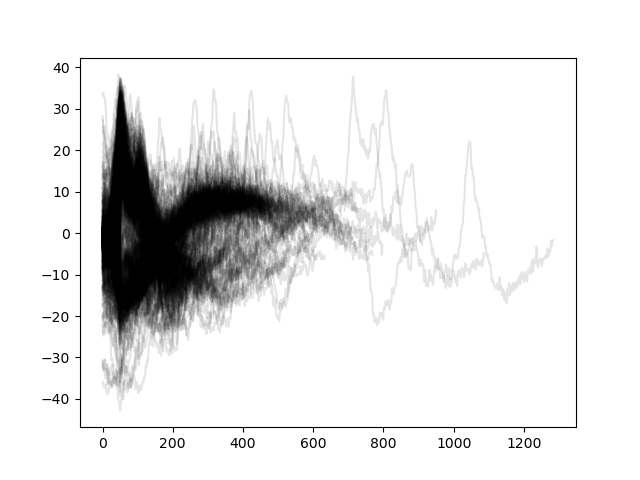

In [186]:
plt.figure()
cccut = []
for c in cutouts:
    plt.plot(c,color='k',alpha=0.1);
    cccut.append(c[:50])

In [187]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(na(cccut))


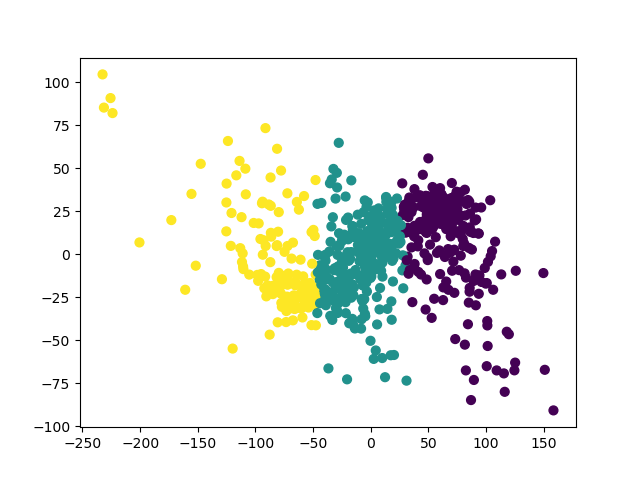

In [189]:
from sklearn.cluster import KMeans

plt.figure()
# plt.plot(X_pca[:,0],X_pca[:,1],'o')

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(X_pca)

scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=40)


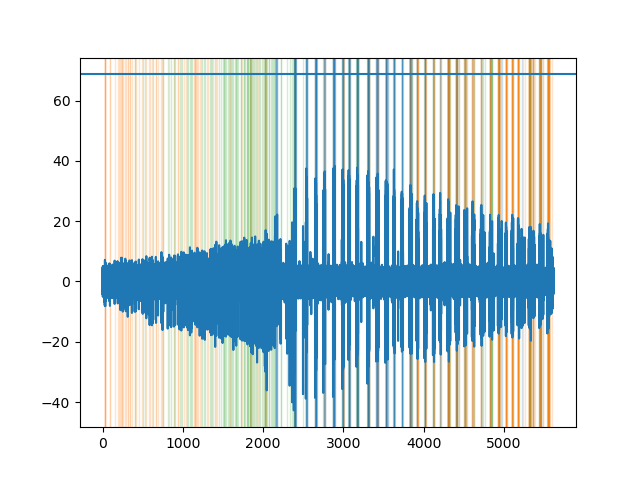

In [191]:
plt.figure()
# plt.plot(np.arange(0,len(filt[:2500000]))*(1/subsampling_rate),data)
plt.plot(np.arange(0,len(filt[:]))*(1/subsampling_rate),orig_data)
plt.axhline(np.mean(data)+5*np.std(data))

label_c = ['C0','C1','C2']
for i,interv in enumerate(intervals):
    plt.axvspan(interv[0],interv[1],alpha=0.2,color=label_c[labels[i]])

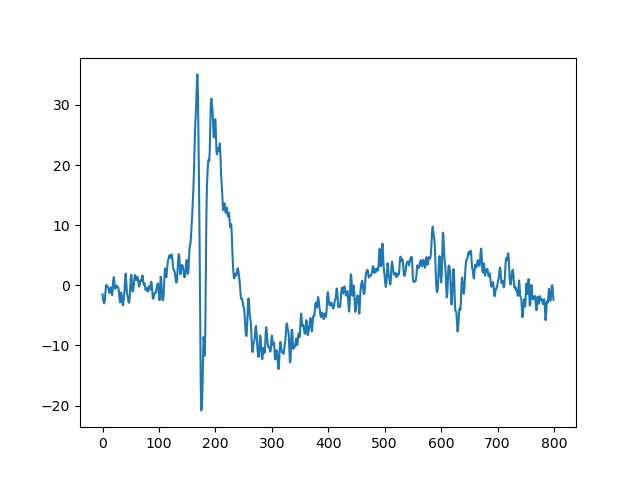

In [25]:
plt.figure()
n_max = 1700000
# plt.plot(np.arange(0,len(filt[:n_max]))*(1/subsampling_rate),(filt[:n_max,163]*adc_step)*mv_scale_factor)
motif = na(na([1402.4,1403.4])*subsampling_rate,dtype=int)

data = filt[motif[0]:motif[1],163]*adc_step*mv_scale_factor
plt.plot(data)

In [ ]:
idx

In [90]:
distance_profile = stumpy.mass(data,na(filt[:n_max,163],dtype=np.float64),)

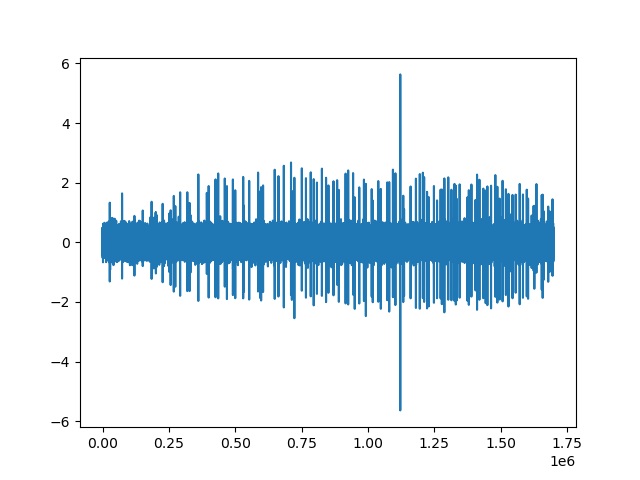

In [94]:
plt.figure()
plt.plot(np.diff(distance_profile))

In [123]:
n_max = 50000
data_all = filt[:n_max,163]*adc_step*mv_scale_factor

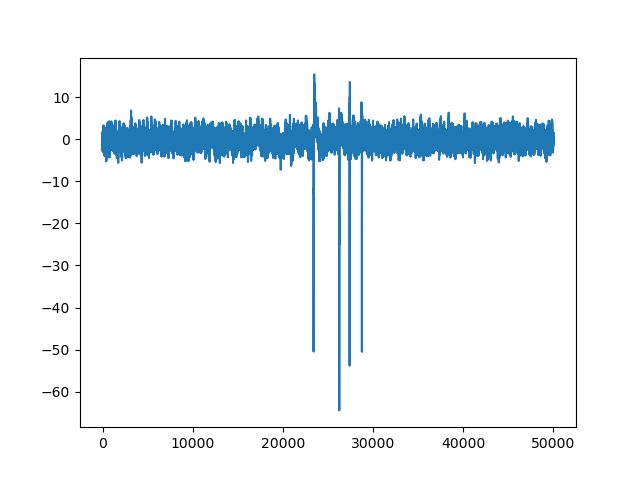

In [124]:
plt.figure()
plt.plot(data_all)

In [136]:
mp = stumpy.stump(data_all, 200)

IndexError: index 4 is out of bounds for axis 1 with size 4

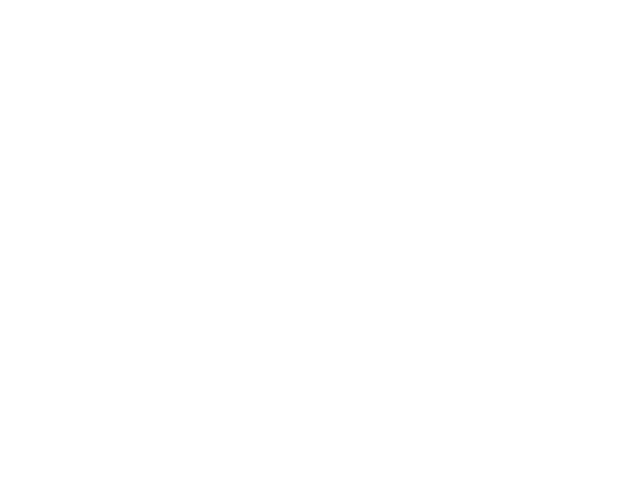

In [140]:
plt.figure()
motif_idx = np.argsort(mp[:, 0])[0]
nearest_neighbor_idx = mp[motif_idx, 4]
plt.plot(data_all)
plt.axvline(motif_idx,color='r')
plt.axvline(nearest_neighbor_idx,color='k')

In [159]:
motif_idx = np.argsort(mp[:, 0])[0]
nearest_neighbor_idx = mp[motif_idx, 2]

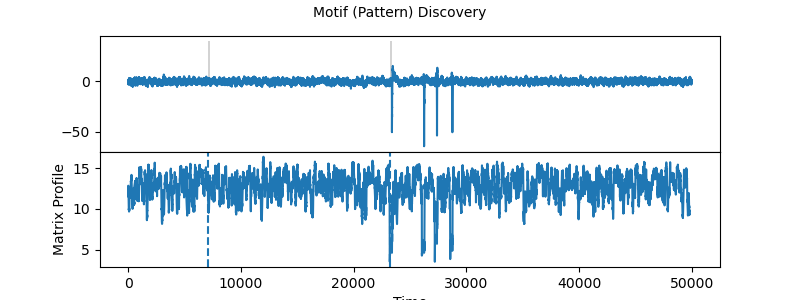

In [160]:
m = 200 
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0},figsize= (8,3))
plt.suptitle('Motif (Pattern) Discovery', fontsize='10')

axs[0].plot(data_all)
# axs[0].set_ylabel('Steam Flow', fontsize='20')
rect = Rectangle((motif_idx, 0), m, 40, facecolor='lightgrey')
axs[0].add_patch(rect)
rect = Rectangle((nearest_neighbor_idx, 0), m, 40, facecolor='lightgrey')
axs[0].add_patch(rect)
axs[1].set_xlabel('Time', fontsize ='10')
axs[1].set_ylabel('Matrix Profile', fontsize='10')
axs[1].axvline(x=motif_idx, linestyle="dashed")
axs[1].axvline(x=nearest_neighbor_idx, linestyle="dashed")
axs[1].plot(mp[:, 0])

In [ ]:
mp = stumpy.stump(steam_df['steam flow'], m)

In [95]:
idxs = np.argsort(distance_profile)

In [33]:
# plt.plot(distance_profile)

In [111]:
k = 200
idxs = np.argpartition(distance_profile, k)[:k]
idxs = idxs[np.argsort(distance_profile[idxs])]

In [116]:
idxs = idxs[np.hstack([True,np.abs(np.diff(idxs))>len(data)])]

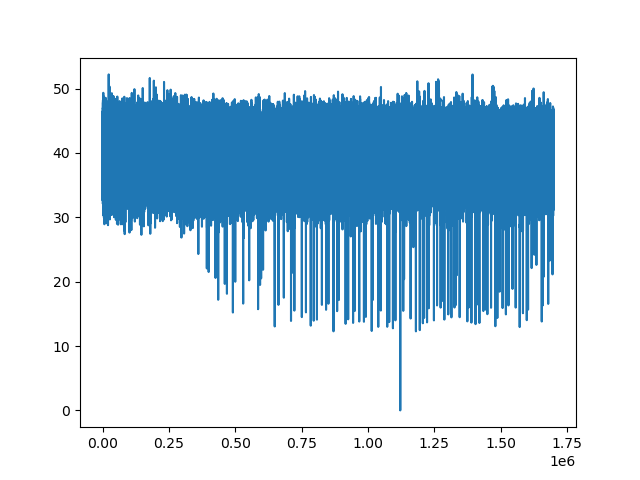

In [87]:
plt.figure()
plt.plot(distance_profile)

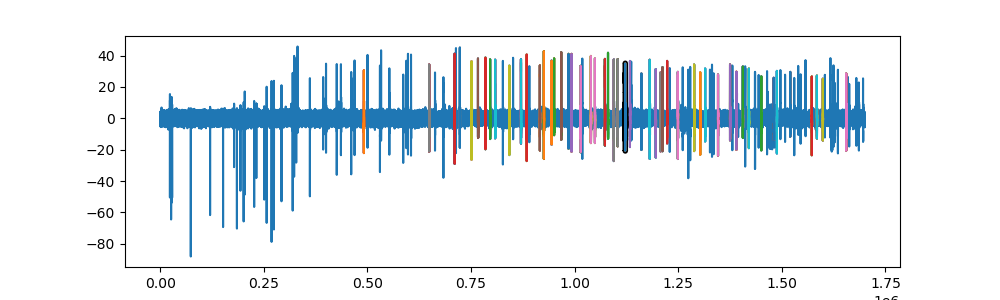

In [119]:

plt.figure(figsize=(10,3))
plt.plot(np.arange(len(data_all)),data_all)
plt.plot(np.arange(motif[0],motif[1],1),filt[motif[0]:motif[1],163]*adc_step*mv_scale_factor,'--k',linewidth=4)
for n in range(len(idxs)):
    plt.plot(np.arange(idxs[n],idxs[n]+len(data)),data_all[idxs[n]:idxs[n]+len(data)],alpha=1)

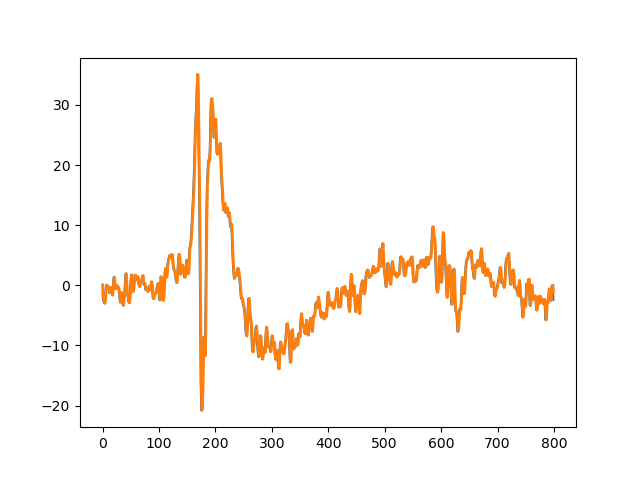

In [45]:
plt.figure()
n = 3
plt.plot(data)
plt.plot(data_all[idxs[n]:idxs[n]+len(data)],'-',
         lw=2, label="Nearest Neighbor Subsequence")

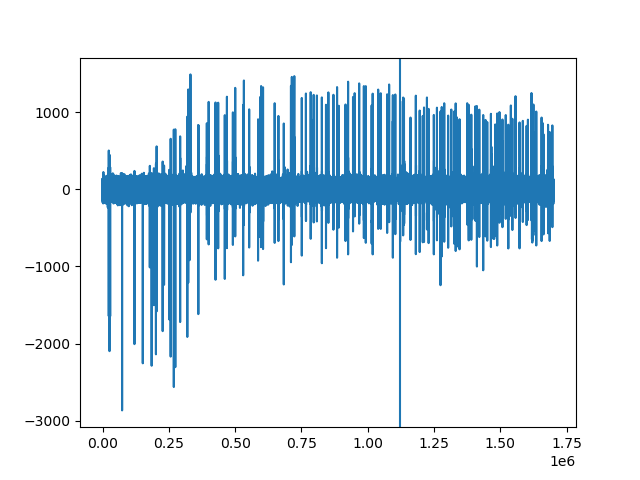

In [17]:
plt.figure()
plt.plot(filt[:n_max,163])
plt.axvline(idx)
plt.plot(range(idx, idx+len(Q_df)), T_df.values[idx:idx+len(Q_df)], lw=2, label="Nearest Neighbor Subsequence")